In [1]:
%load_ext autoreload

In [2]:
import pandas as pd
import seaborn as sns
%aimport AD_predictor_tools
%aimport AD_comparison_tools
%aimport PlottingTools
import matplotlib.pyplot as plt


In [3]:
TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
TFs["uniprotID"] = TFs["id"].str.split("|").str[1]
TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0
...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8


In [4]:
activator_TFs = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins_activators.txt", sep = "\t")
activator_TFs = activator_TFs[["uniprotID"]]
activator_TFs["TF_type"] = "activator"
activator_TFs

,uniprotID,TF_type
0,A6NJG6,activator
1,A8MTJ6,activator
2,A8MYZ6,activator
3,A8MZ59,activator
4,O00321,activator
...,...,...
441,Q9Y5R6,activator
442,Q9Y5W3,activator
443,Q9Y692,activator
444,Q9Y6Q9,activator


In [5]:
merged_TFs = TFs.merge(activator_TFs, on="uniprotID", how="left")
merged_TFs["TF_type"] = merged_TFs["TF_type"].fillna("other")
merged_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID,TF_type
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0,other
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6,other
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2,other
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519,other
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0,other
...,...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9,activator
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6,other
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0,other
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8,other


In [7]:
merged_TFs["TF_len"] = merged_TFs["ProteinSeq"].str.len()
merged_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID,TF_type,TF_len
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0,other,522
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6,other,867
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2,other,475
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519,other,330
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0,other,619
...,...,...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9,activator,1424
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6,other,833
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0,other,1596
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8,other,837


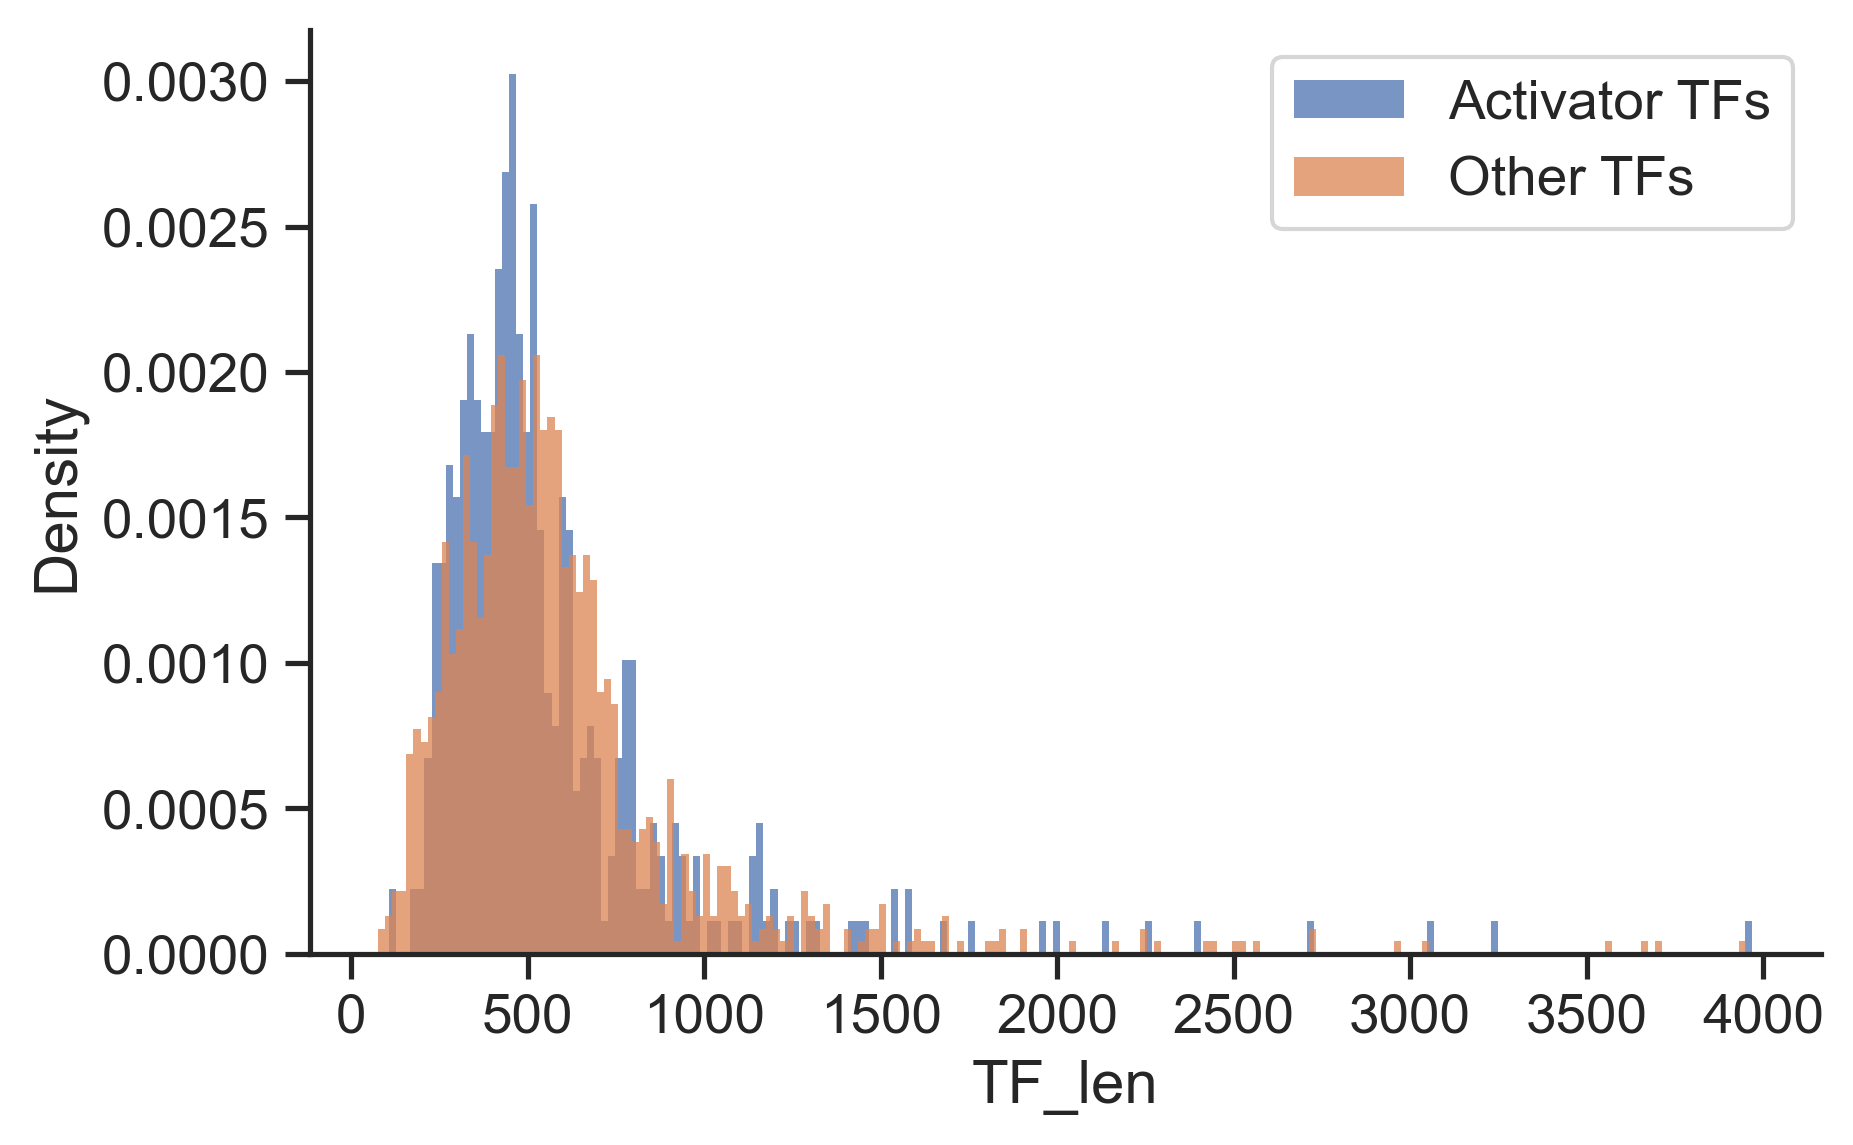

In [16]:
plt.figure(dpi = 300)
sns.histplot(merged_TFs[merged_TFs["TF_type"] == "activator"]["TF_len"], stat = 'density', label = "Activator TFs", binwidth = 20, edgecolor = 'none')
sns.histplot(merged_TFs[merged_TFs["TF_type"] == "other"]["TF_len"], stat = 'density', label = "Other TFs", binwidth = 20, edgecolor = 'none')
plt.legend()
sns.despine()

In [196]:
amino_acids = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

for AA in amino_acids:
    merged_TFs[AA] = merged_TFs["ProteinSeq"].str.count(AA)
    merged_TFs[AA + "_prop"] = merged_TFs[AA] / merged_TFs["ProteinSeq"].str.len()

merged_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID,TF_type,A_prop,R_prop,N_prop,D_prop,...,L,K,M,F,P,S,T,W,Y,V
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0,other,0.049808,0.051724,0.032567,0.028736,...,35,45,3,17,21,49,31,3,15,14
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6,other,0.068051,0.044983,0.048443,0.032295,...,73,64,16,26,79,104,51,3,13,56
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2,other,0.086316,0.040000,0.044211,0.023158,...,41,39,11,23,52,33,26,0,11,23
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519,other,0.030303,0.063636,0.027273,0.030303,...,18,18,11,6,18,40,22,4,5,22
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0,other,0.088853,0.051696,0.033926,0.074313,...,60,32,14,31,58,28,20,4,15,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9,activator,0.049157,0.047753,0.066011,0.044944,...,111,55,71,34,111,179,63,5,27,59
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6,other,0.031212,0.049220,0.048019,0.013205,...,57,92,7,49,34,51,35,3,24,25
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0,other,0.061404,0.051378,0.040100,0.043233,...,115,166,36,35,166,192,90,8,30,67
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8,other,0.076464,0.044205,0.032258,0.051374,...,61,66,13,18,63,76,61,10,17,60


In [65]:
from scipy.stats import ks_2samp

activator_TFs = merged_TFs[merged_TFs["TF_type"] == "activator"]
non_activator_TFs = merged_TFs[merged_TFs["TF_type"] != "activator"]

KS_dict = {}

for AA in amino_acids:
    activator_values = activator_TFs[AA + "_prop"].dropna()
    non_activator_values = non_activator_TFs[AA + "_prop"].dropna()
    ks_stat, p_value = ks_2samp(activator_values, non_activator_values)
    KS_dict[AA] = (ks_stat, p_value)

KS_dict

{'A': (0.2536591082880868, 9.500565400439534e-19),
 'R': (0.2160343681433748, 1.1036355472353133e-13),
 'N': (0.05543515433771005, 0.2625470006779813),
 'D': (0.28422692811663036, 1.727441303296158e-23),
 'C': (0.3650731437398411, 8.009820057596367e-39),
 'E': (0.2541202193351547, 8.147459616336955e-19),
 'Q': (0.056255547742285035, 0.2474057770060414),
 'G': (0.10691436015078332, 0.0011353763227973247),
 'H': (0.32364039486476, 1.8910275582275175e-30),
 'I': (0.1149818821784423, 0.00035378142745565015),
 'L': (0.20079272674175092, 7.171525032587012e-12),
 'K': (0.34459212806590817, 1.517417387131556e-34),
 'M': (0.25567839041503837, 4.81469452722749e-19),
 'F': (0.1972844401919759, 1.7934784384188852e-11),
 'P': (0.30663116111604244, 2.5056500483899625e-27),
 'S': (0.23429052301520514, 4.893223269288485e-16),
 'T': (0.06445179660391714, 0.12994739036029215),
 'W': (0.07275755933922787, 0.06182809632500976),
 'Y': (0.037278906859411085, 0.7430419252485808),
 'V': (0.11894743718322631, 

In [66]:
sorted_KS_dict = dict(sorted(KS_dict.items(), key=lambda item: item[1][1]))
sorted_KS_dict

{'C': (0.3650731437398411, 8.009820057596367e-39),
 'K': (0.34459212806590817, 1.517417387131556e-34),
 'H': (0.32364039486476, 1.8910275582275175e-30),
 'P': (0.30663116111604244, 2.5056500483899625e-27),
 'D': (0.28422692811663036, 1.727441303296158e-23),
 'M': (0.25567839041503837, 4.81469452722749e-19),
 'E': (0.2541202193351547, 8.147459616336955e-19),
 'A': (0.2536591082880868, 9.500565400439534e-19),
 'S': (0.23429052301520514, 4.893223269288485e-16),
 'R': (0.2160343681433748, 1.1036355472353133e-13),
 'L': (0.20079272674175092, 7.171525032587012e-12),
 'F': (0.1972844401919759, 1.7934784384188852e-11),
 'V': (0.11894743718322631, 0.00019336861225221268),
 'I': (0.1149818821784423, 0.00035378142745565015),
 'G': (0.10691436015078332, 0.0011353763227973247),
 'W': (0.07275755933922787, 0.06182809632500976),
 'T': (0.06445179660391714, 0.12994739036029215),
 'Q': (0.056255547742285035, 0.2474057770060414),
 'N': (0.05543515433771005, 0.2625470006779813),
 'Y': (0.0372789068594110

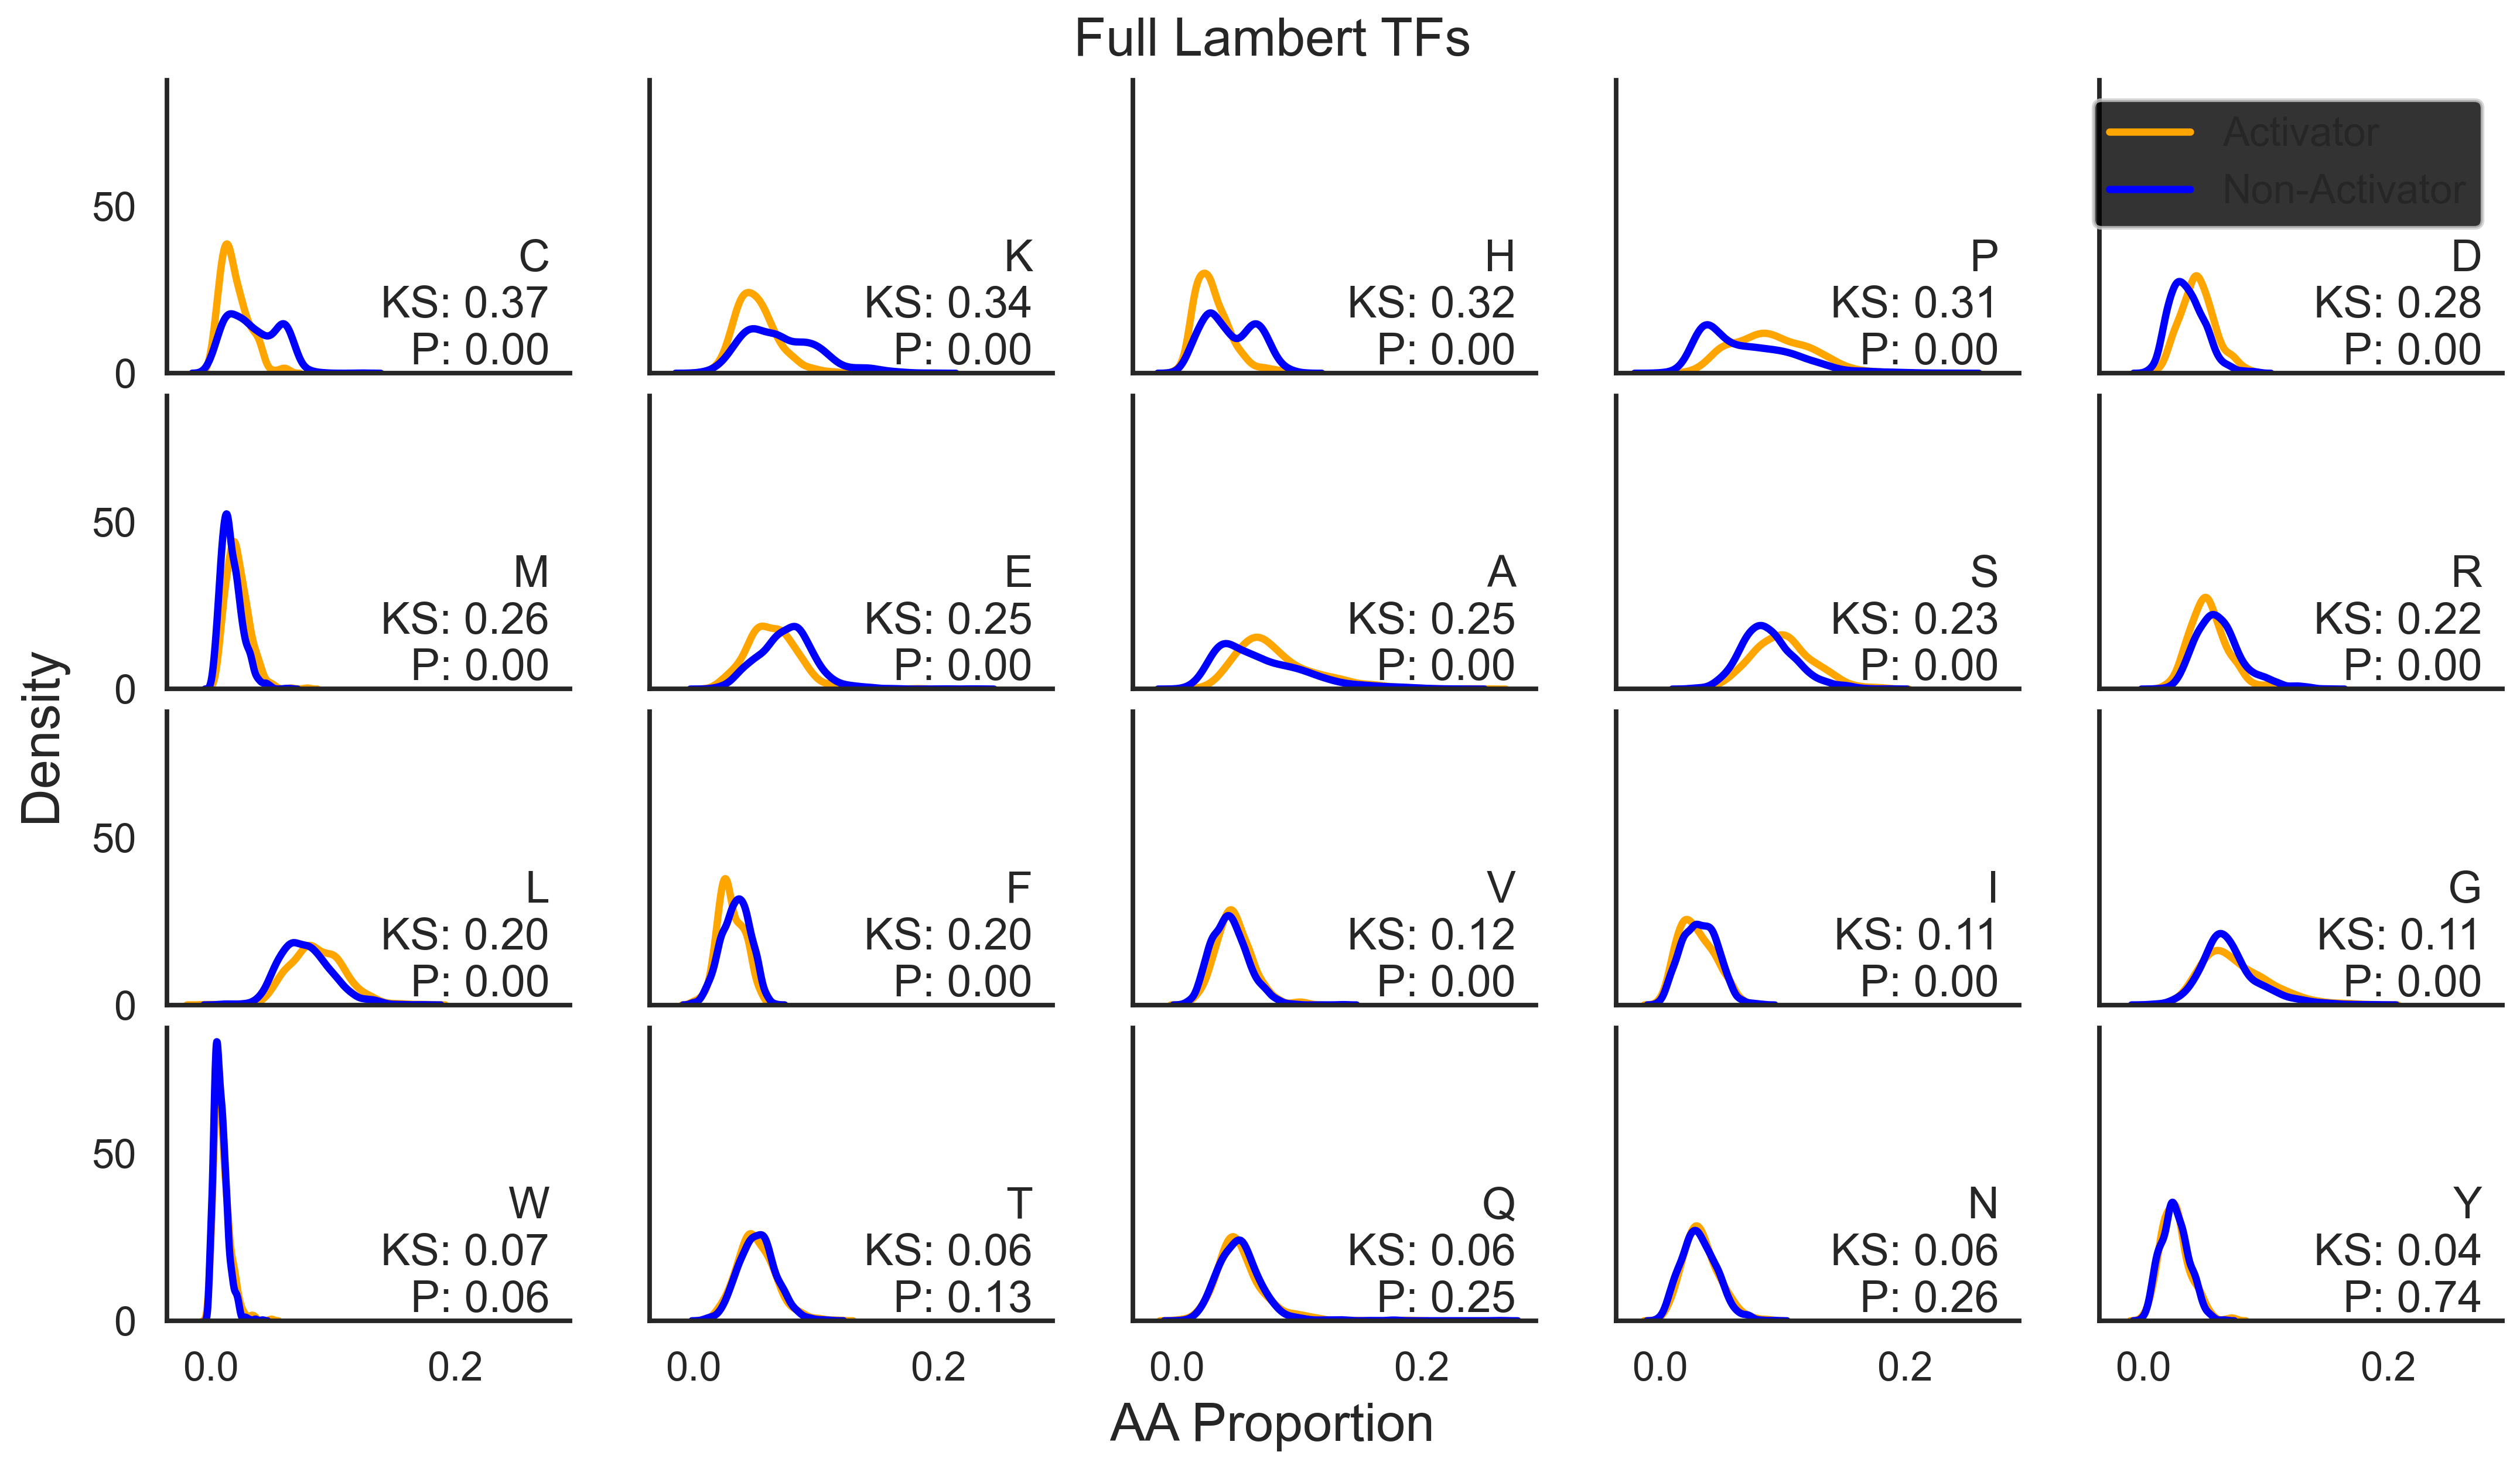

In [187]:
fig, axes = plt.subplots(4, 5, figsize=(14, 8), sharex = True, sharey = True, dpi = 300)

for i, AA in enumerate(sorted_KS_dict.keys()):
    ax = axes.flatten()[i]
    sns.kdeplot(data=activator_TFs, x=AA + "_prop", ax=ax, color='orange', label='Activator', lw = 3)
    sns.kdeplot(data=non_activator_TFs, x=AA + "_prop", ax=ax, color='blue', label='Non-Activator', lw = 3)
    
    # Add KS statistic and p-value as text on the plot
    ks_stat, p_value = sorted_KS_dict[AA]
    ax.text(0.95, 0, AA + f"\nKS: {ks_stat:.2f}\nP: {p_value:.2f}", transform=ax.transAxes, fontsize='medium', verticalalignment='bottom', ha = 'right')
    ax.set_ylabel("")
    if i == 4:
        ax.legend()
    ax.set_xlabel("")

plt.suptitle("Full Lambert TFs", y = 1.01)
fig.supxlabel("AA Proportion", y = -0.01)
fig.supylabel("Density", x = -0.01)
plt.tight_layout(pad=0)
sns.despine()

In [103]:
# Which AAs are most conserved?

import glob

perc_ident_paths = glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/*")
big_df = pd.concat([pd.read_csv(path) for path in perc_ident_paths], ignore_index=True)
big_df

,Unnamed: 0,percent_identity,pos
0,0,97.722567,M
1,1,97.515528,E
2,2,91.304348,A
3,3,97.515528,L
4,4,97.515528,Q
...,...,...,...
663467,337,96.995708,N
663468,338,98.497854,F
663469,339,98.497854,N
663470,340,98.497854,F


In [139]:
sorted_pos

CategoricalIndex(['Y', 'F', 'W', 'C', 'K', 'L', 'H', 'E', 'R', 'Q', 'D', 'P',
                  'G', 'I', 'M', 'N', 'S', 'V', 'A', 'T'],
                 categories=['Y', 'F', 'W', 'C', ..., 'S', 'V', 'A', 'T'], ordered=True, dtype='category', name='pos')

In [158]:
# Calculate the average percent_identity for each pos and sort
sorted_pos = big_df.groupby("pos")["percent_identity"].mean().sort_values(ascending=True).index
sorted_pos

CategoricalIndex(['T', 'A', 'V', 'S', 'N', 'M', 'I', 'G', 'P', 'D', 'Q', 'R',
                  'E', 'H', 'L', 'K', 'C', 'W', 'F', 'Y'],
                 categories=['Y', 'F', 'W', 'C', ..., 'S', 'V', 'A', 'T'], ordered=True, dtype='category', name='pos')

Text(0.5, 0.87, 'Lambert TFs')

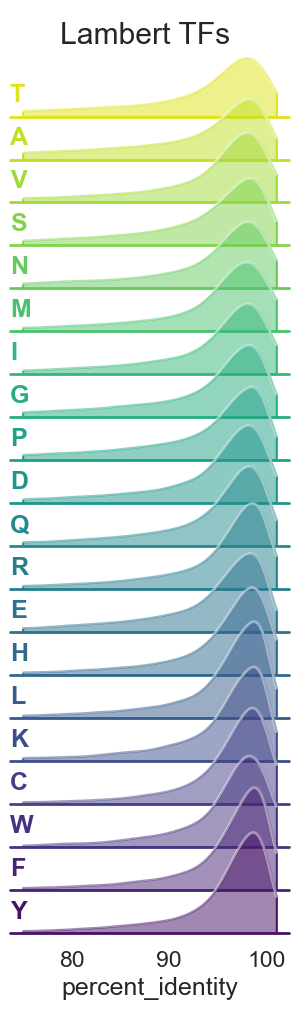

In [177]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)

sns.set_context('talk')
g = sns.FacetGrid(big_df, row="pos", hue="pos", aspect=6, height=0.6, palette="viridis", row_order = sorted_pos)

# Draw the densities in a few steps
g.map(sns.kdeplot, "percent_identity",
      bw_adjust=.5, clip=(75, 101),
      fill=True, alpha=0.5, linewidth=1.5)
g.map(sns.kdeplot, "percent_identity", clip=(75, 101), color="w", lw=2, bw_adjust=.5, alpha=0.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "percent_identity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.6)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.figure.suptitle("Lambert TFs", y = 0.87)

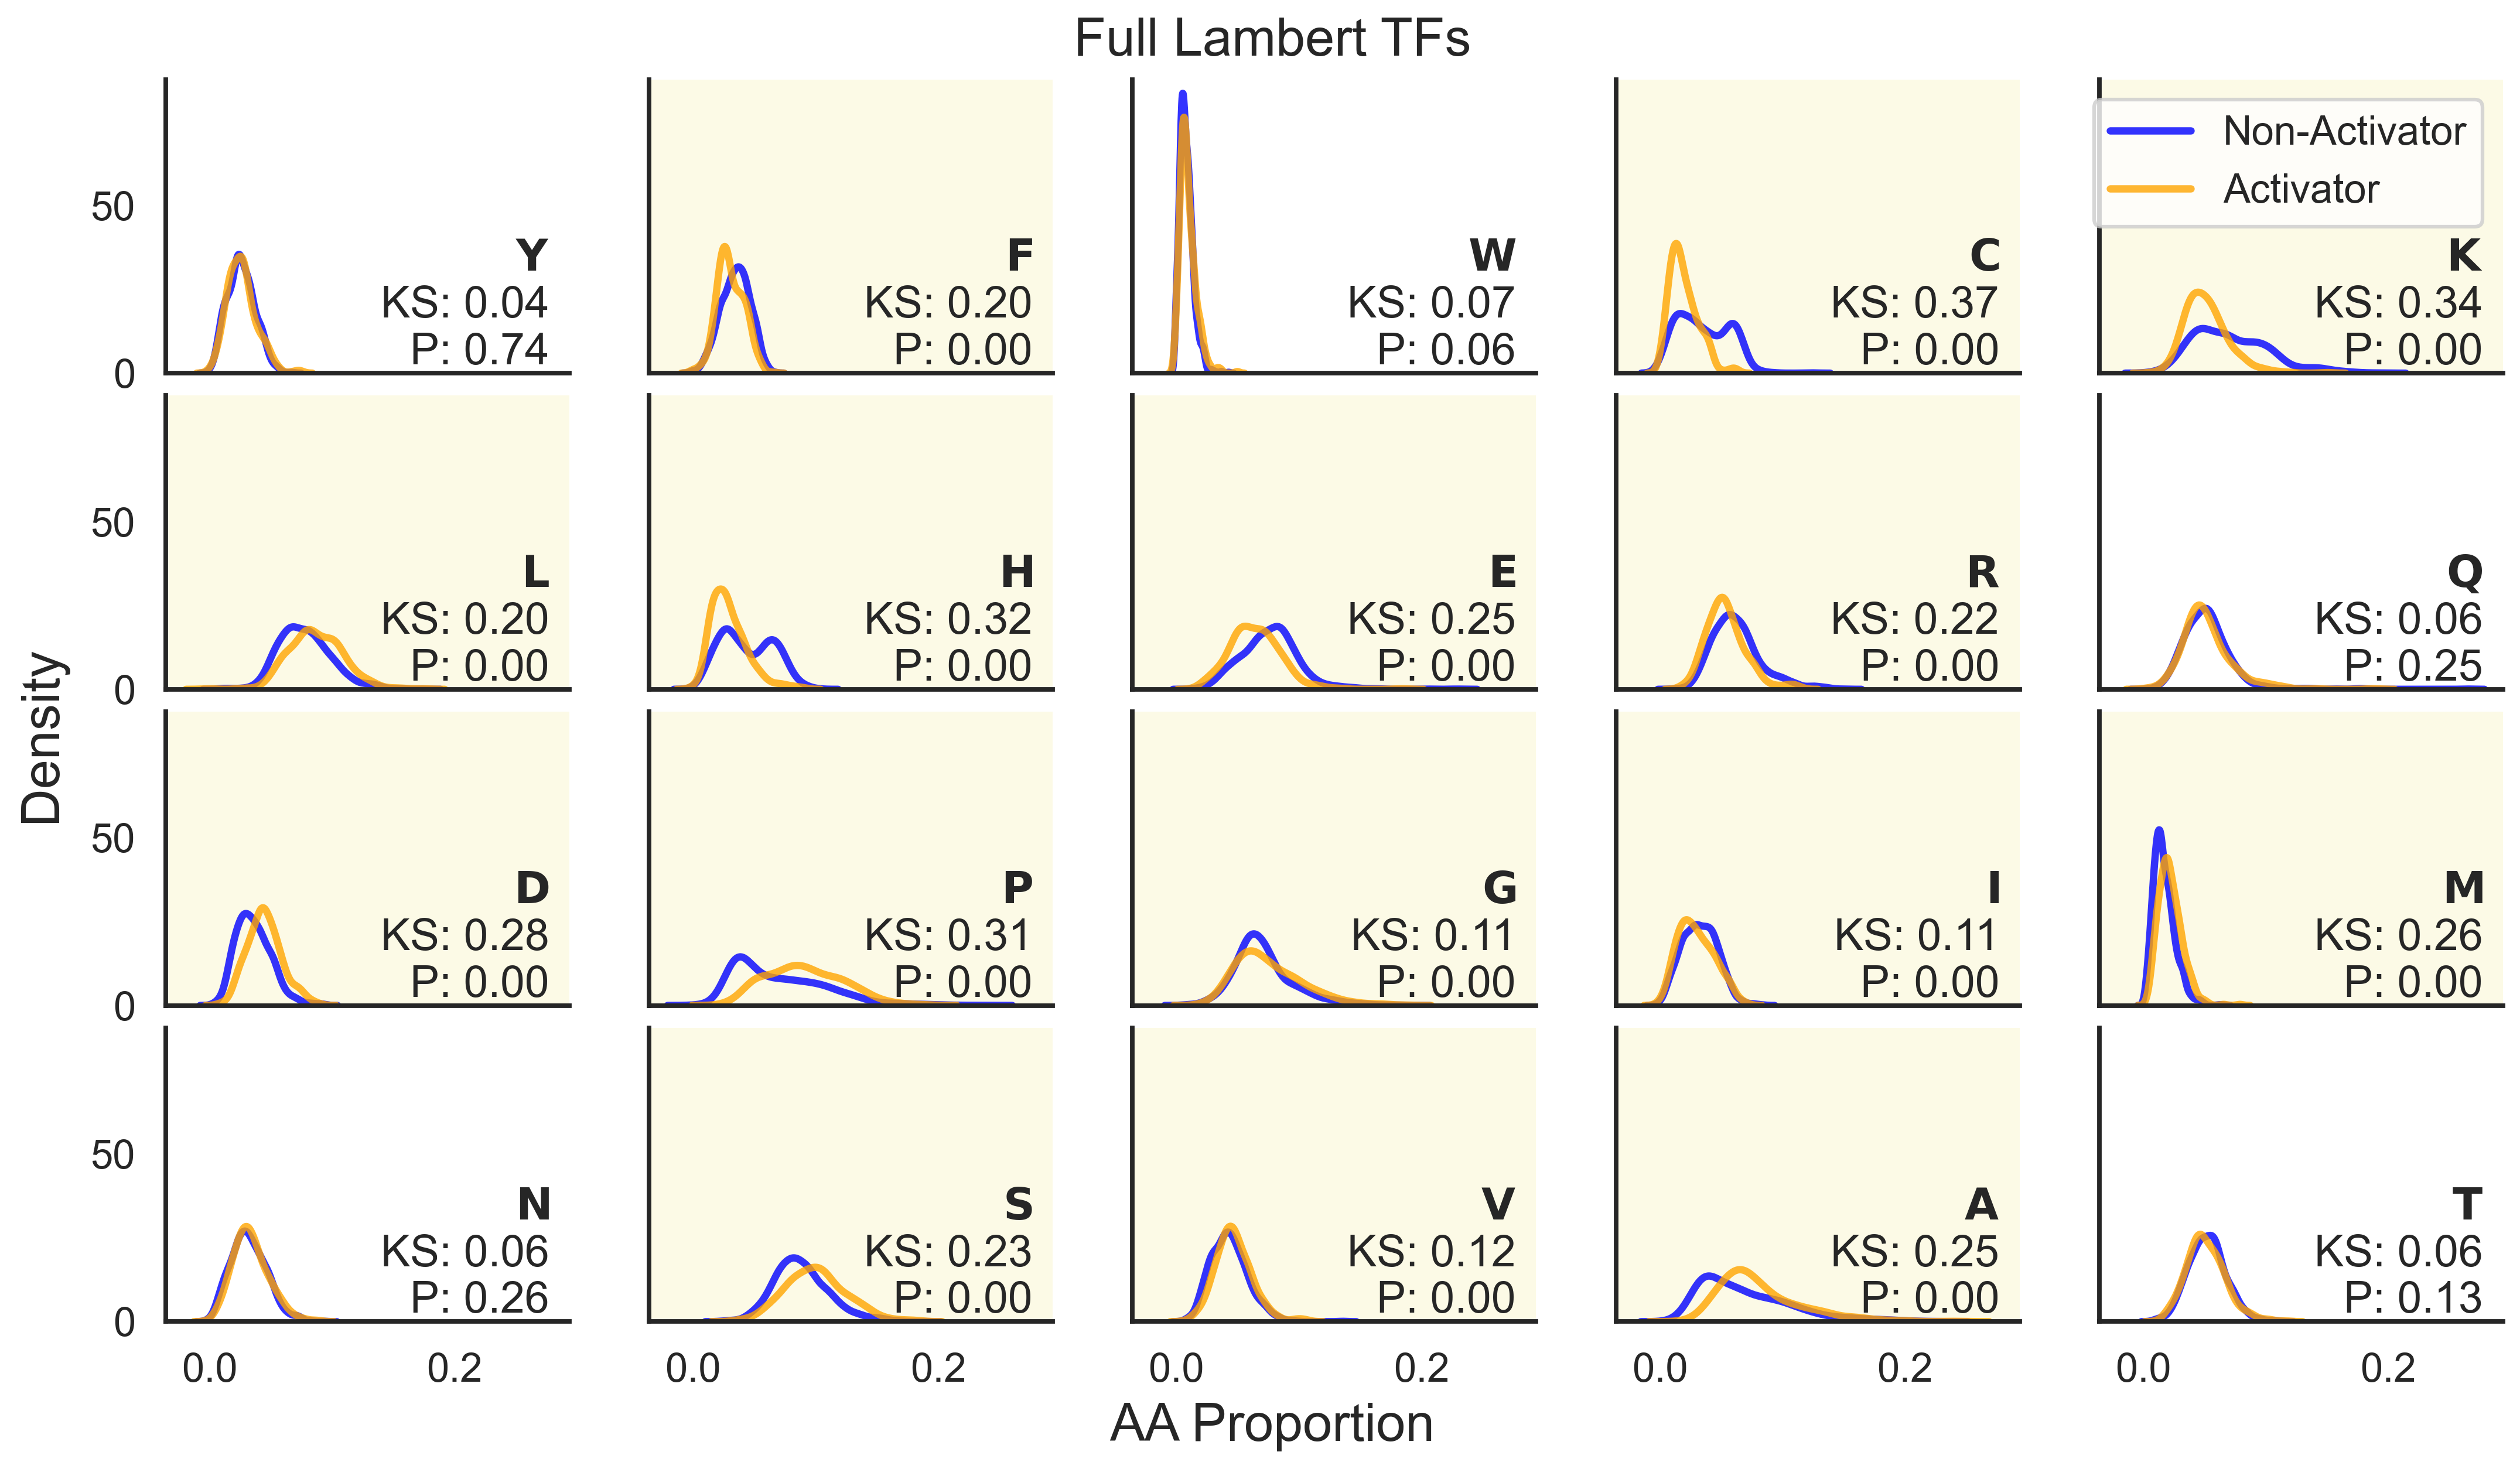

In [194]:
fig, axes = plt.subplots(4, 5, figsize=(14, 8), sharex = True, sharey = True, dpi = 300)

for i, AA in enumerate(reversed(sorted_pos)):
    ax = axes.flatten()[i]
    sns.kdeplot(data=non_activator_TFs, x=AA + "_prop", ax=ax, color='blue', label='Non-Activator', lw=3, alpha = 0.8)
    sns.kdeplot(data=activator_TFs, x=AA + "_prop", ax=ax, color='orange', label='Activator', lw=3, alpha = 0.8)
    
    # Add KS statistic and p-value as text on the plot
    ks_stat, p_value = sorted_KS_dict[AA]
    ax.text(0.95, 0, f"$\\mathbf{{{AA}}}$" + f"\nKS: {ks_stat:.2f}\nP: {p_value:.2f}", transform=ax.transAxes, fontsize='medium', verticalalignment='bottom', ha='right')
    
    # Set background color to pale yellow if p-value > 0.05
    if p_value < 0.05:
        ax.set_facecolor('#fcfae6')  # Pale yellow color
    
    if i == 4:
        legend = ax.legend()
        legend.get_frame().set_facecolor('white')  # Set legend background to white
    ax.set_xlabel("")
    ax.set_ylabel(None)

plt.suptitle("Full Lambert TFs", y = 1.01)
fig.supxlabel("AA Proportion", y = -0.01)
fig.supylabel("Density", x = -0.01)
plt.tight_layout(pad=-0.01)
sns.despine()

# Removing ADs from calculation

In [197]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical_with_alerasool.csv")
for AA in amino_acids:
    known_ADs[AA] = known_ADs["ProteinRegionSeq"].str.count(AA)

known_ADs["len"] = known_ADs["ProteinRegionSeq"].str.len()
known_ADs

,Unnamed: 0,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,...,K,M,F,P,S,T,W,Y,V,len
0,0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,"DelRosso et al. (Q6UWZ7, 121_200)",CR,...,3,2,4,3,12,6,0,2,6,80
1,1,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,...,0,0,1,0,0,0,0,0,1,9
2,2,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,...,0,0,1,0,0,0,0,0,0,3
3,3,AHR,532,848,P35869,"[['P35869'], ['P35869'], ['P35869']]",ENST00000242057 / nan / ENST00000242057,P35869 / P35869 / P35869,"DelRosso et al. (P35869, 532_641) // PMID: 879...",TF / TF / TF,...,11,11,18,26,26,17,1,12,15,317
4,4,AKAP8,2,81,O43823,[['O43823']],ENST00000269701,O43823,"DelRosso et al. (O43823, 2_81)",TF,...,1,2,0,3,6,6,3,10,2,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
756,757,ATXN7L3,1,120,Q14CW9,"[['Q14CW9', 'Q14CW9-2']]",NaN,NaN,Alerasool et al,TF,...,7,5,8,4,11,1,1,2,6,120
757,758,FAM22F,361,500,A1L443,[['A1L443']],NaN,NaN,Alerasool et al,TF,...,6,2,3,18,6,6,0,2,9,140
758,759,SS18L2,18,77,Q9UHA2,[['Q9UHA2']],NaN,NaN,Alerasool et al,TF,...,2,1,0,1,3,4,0,3,3,60
759,760,SERTAD2,201,260,Q14140,[['Q14140']],NaN,NaN,Alerasool et al,TF,...,2,2,4,3,6,7,0,1,0,60


In [205]:
known_ADs_grouped = known_ADs[["uniprotID"] + amino_acids + ["len"]].groupby("uniprotID").sum().reset_index()
known_ADs_grouped

,uniprotID,A,R,N,D,C,E,Q,G,H,...,K,M,F,P,S,T,W,Y,V,len
0,A0A024R0Y4,11,4,4,14,0,7,1,1,4,...,5,4,7,6,5,5,1,3,3,100
1,A0A087WXG3,15,2,3,2,5,2,5,6,2,...,4,2,4,8,3,3,0,1,3,80
2,A0A669KBM4,3,2,11,13,2,15,11,9,7,...,3,8,8,12,27,16,1,3,5,179
3,A1L443,6,7,1,8,1,23,11,8,3,...,6,2,3,18,6,6,0,2,9,140
4,A6NJG6,11,3,8,9,1,7,13,6,1,...,5,3,10,15,29,11,4,9,7,174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,Q9Y692,12,2,2,7,0,17,7,7,5,...,3,5,1,10,20,16,0,1,17,152
590,Q9Y6F1,9,1,3,6,1,14,11,6,5,...,6,1,2,9,8,5,0,4,6,120
591,Q9Y6J9,13,7,1,8,1,6,3,17,0,...,4,1,5,16,9,4,1,2,1,110
592,Q9Y6Q9,44,32,50,32,5,27,107,71,15,...,25,51,15,71,99,32,3,13,30,804


In [213]:
TFs_with_ADs = pd.merge(merged_TFs, known_ADs_grouped, on = "uniprotID", how = "left", suffixes = ("_TF", "_AD"))
for AA in amino_acids:
    TFs_with_ADs[AA + "_TF-AD"] = TFs_with_ADs[AA + "_TF"] - TFs_with_ADs[AA + "_AD"]
    TFs_with_ADs[AA + "_TF-AD"] = TFs_with_ADs[AA + "_TF-AD"].fillna(TFs_with_ADs[AA + "_TF"])
    TFs_with_ADs["len"] = TFs_with_ADs["len"].fillna(0)
    TFs_with_ADs[AA + "_TF-AD_prop"] = TFs_with_ADs[AA + "_TF-AD"] / (TFs_with_ADs["ProteinSeq"].str.len() - TFs_with_ADs["len"])

TFs_with_ADs 

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID,TF_type,A_prop,R_prop,N_prop,D_prop,...,S_TF-AD,S_TF-AD_prop,T_TF-AD,T_TF-AD_prop,W_TF-AD,W_TF-AD_prop,Y_TF-AD,Y_TF-AD_prop,V_TF-AD,V_TF-AD_prop
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0,other,0.049808,0.051724,0.032567,0.028736,...,49.0,0.093870,31.0,0.059387,3.0,0.005747,15.0,0.028736,14.0,0.026820
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6,other,0.068051,0.044983,0.048443,0.032295,...,104.0,0.119954,51.0,0.058824,3.0,0.003460,13.0,0.014994,56.0,0.064591
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2,other,0.086316,0.040000,0.044211,0.023158,...,33.0,0.069474,26.0,0.054737,0.0,0.000000,11.0,0.023158,23.0,0.048421
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519,other,0.030303,0.063636,0.027273,0.030303,...,40.0,0.121212,22.0,0.066667,4.0,0.012121,5.0,0.015152,22.0,0.066667
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0,other,0.088853,0.051696,0.033926,0.074313,...,28.0,0.045234,20.0,0.032310,4.0,0.006462,15.0,0.024233,22.0,0.035541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9,activator,0.049157,0.047753,0.066011,0.044944,...,80.0,0.129032,31.0,0.050000,2.0,0.003226,14.0,0.022581,29.0,0.046774
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6,other,0.031212,0.049220,0.048019,0.013205,...,51.0,0.061224,35.0,0.042017,3.0,0.003601,24.0,0.028812,25.0,0.030012
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0,other,0.061404,0.051378,0.040100,0.043233,...,192.0,0.120301,90.0,0.056391,8.0,0.005013,30.0,0.018797,67.0,0.041980
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8,other,0.076464,0.044205,0.032258,0.051374,...,76.0,0.090800,61.0,0.072879,10.0,0.011947,17.0,0.020311,60.0,0.071685


In [214]:
TFs_with_ADs.columns

Index(['Unnamed: 0', 'id', 'ProteinSeq', 'DBD_coords_merged', 'uniprotID',
       'TF_type', 'A_prop', 'R_prop', 'N_prop', 'D_prop',
       ...
       'S_TF-AD', 'S_TF-AD_prop', 'T_TF-AD', 'T_TF-AD_prop', 'W_TF-AD',
       'W_TF-AD_prop', 'Y_TF-AD', 'Y_TF-AD_prop', 'V_TF-AD', 'V_TF-AD_prop'],
      dtype='object', length=107)

In [229]:

activator_TFs = TFs_with_ADs[TFs_with_ADs["TF_type"] == "activator"]
non_activator_TFs = TFs_with_ADs[TFs_with_ADs["TF_type"] != "activator"]

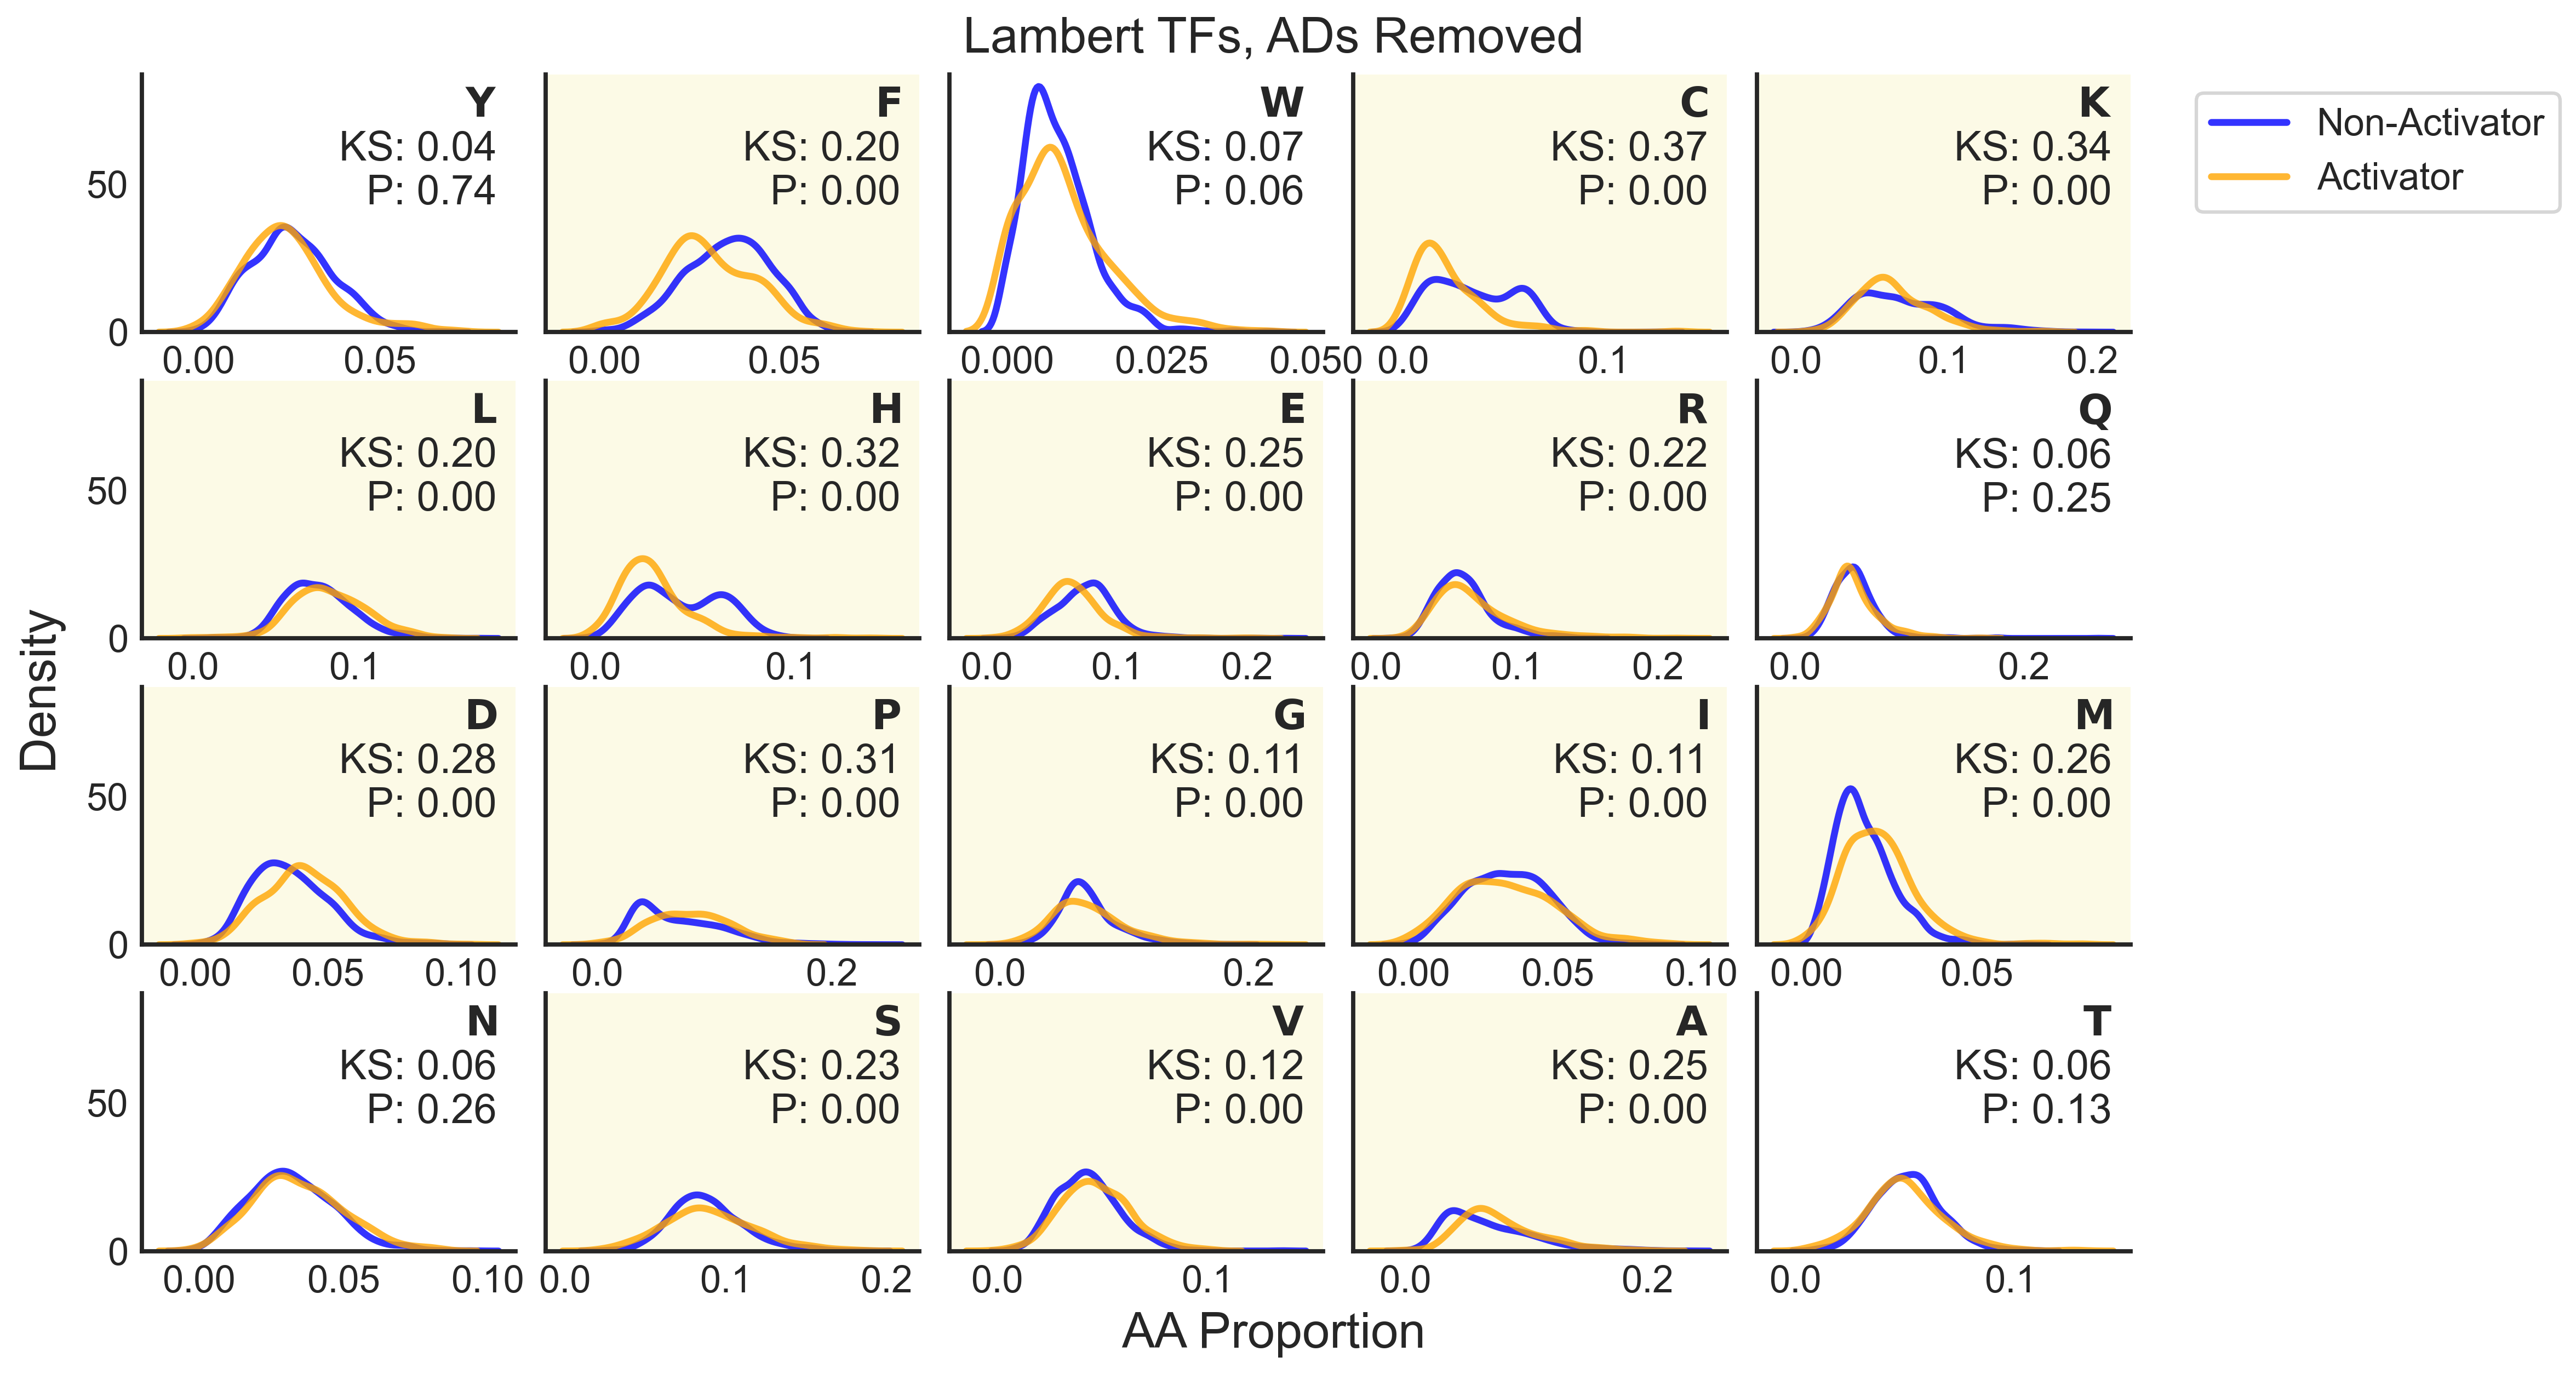

In [252]:
fig, axes = plt.subplots(4, 5, figsize=(15, 8), sharey=True, dpi=300)

for i, AA in enumerate(reversed(sorted_pos)):
    ax = axes.flatten()[i]
    sns.kdeplot(data=non_activator_TFs, x=AA + "_TF-AD_prop", ax=ax, color='blue', label='Non-Activator', lw=3, alpha=0.8)
    sns.kdeplot(data=activator_TFs, x=AA + "_TF-AD_prop", ax=ax, color='orange', label='Activator', lw=3, alpha=0.8)
    
    # Add KS statistic and p-value as text on the plot
    ks_stat, p_value = sorted_KS_dict[AA]
    ax.text(0.95, 0.95, f"$\\mathbf{{{AA}}}$" + f"\nKS: {ks_stat:.2f}\nP: {p_value:.2f}", transform=ax.transAxes, fontsize='medium', verticalalignment='top', ha='right')
    
    # Set background color to pale yellow if p-value > 0.05
    if p_value < 0.05:
        ax.set_facecolor('#fcfae6')  # Pale yellow color
    
    if i == 4:
        legend = ax.legend(bbox_to_anchor=(2.2, 1))
        legend.get_frame().set_facecolor('white')  # Set legend background to white
    ax.set_xlabel("")
    ax.set_ylabel(None)
    ax.tick_params(axis='x', which='major', tick1On=False, tick2On=False, pad=-3)
    ax.tick_params(axis='y', which='major', tick1On=False, tick2On=False, pad=-3)

plt.suptitle("Lambert TFs, ADs Removed", y=1.01)
fig.supxlabel("AA Proportion", y=-0.01)
fig.supylabel("Density", x=-0.01)
plt.tight_layout(pad=-0.01)
sns.despine()